In [8]:
area = pd.read_csv("area_protegida.csv")

Parte 2 – Preguntas de análisis (10 preguntas)

---Filtrar: condición de una columna, por más de una columna.

       preguntas:

1.calculo: de todas las areas de jurisdiccion jap, cual es su subtipo mas frecuente?

       respuesta:

In [81]:
filtr2 = area["jap"].value_counts()
print(filtr2)

jap
 3    222
 2    103
 5     33
 4     32
 0      3
-1      2
Name: count, dtype: int64


explicacion: con una variable, se filtro por jap y sobre ella se hizo una value_counts

2.calculo: ¿cual es el valor maximo total de las longitudes y latitudes?

      respuesta:

In [9]:
filtr1 = area["lat"].max()
filtr2 = area["lng"].max()
print(filtr1)
print(filtr2)

-22.1586842099999
-53.7909397257891


explicacion: se utilizaron por dos filtros diferentes (uno latitud y otro longitud)

1.filtro:¿Cuál es el área promedio de los Parques Nacionales (tap == 1 y jap == 2)? ¿Y de las Reservas Provinciales (tap == 2 y jap == 3)?

      Respuesta:

In [10]:
filtr = area[(area["tap"] == 1)&(area.jap == 2)]
filtr.area.mean()

np.float64(913448.268292683)

In [11]:
filtr = area[(area["tap"] == 2)&(area.jap == 3)]
filtr.area.mean()

np.float64(1331852.903030303)

explicacion: aqui se utiliza "&" para adjuntar dos  instancias y filtrarlas como una sola variable

2.filtro: filtrar todas las areas nacionales (tap == 2) que sean menores a la latitud -34

In [12]:
filtr1 = area[area["lng"] < -34]
filtr2 = filtr1[filtr1["jap"] == 2]
print(filtr2.value_counts())

lat         lng         gid  entidad  objeto          fna                                                                                                gna                                                nam                                             tap  jap  caa  fdc                                       sag  area    
-53.546655  -68.041297  362  falso    Área protegida  Sitio RAMSAR y Reserva Hemisférica Costa Atlántica de Tierra del Fuego                             Sitio RAMSAR y Reserva Hemisférica                 Costa Atlántica de Tierra del Fuego             2    2    17   SIB/IGN/Ley Provincial Nº 415/1998        IGN  762166      1
-31.404445  -64.357709  157  falso    Área protegida  Reserva Natural de la Defensa La Calera                                                            Reserva Natural de la Defensa                      La Calera                                       2    2    17   SIB/IGN/Protocolo adicional Nº 05/2009    IGN  136225      1
-47.925458  -72.31751

explicacion: utilizamos dos filtros, una variable para establecer el punto de salida para comenzar a filtrar (filtr1) y otro que establece el tipo jap 2 por el que se va a filtrar.

3.filtro: ¿cual es la area protegida cuyo codigo gid es 262?

         Respuesta:

In [13]:
filtr1 = area[area["gid"] == 262]
filtr2 = filtr1["nam"]
print(filtr2)


268    del Sistema Domuyo
Name: nam, dtype: str


explicacion: se filtro primero con una variable que almacena el codigo gid.
luego con otra variable se filtro por el nombre del area.

---Gráficos: torta, barra(datos ordenados), línea

    preguntas:

1.Gráfico: crear un grafico potly bar que identifique todos los tipos jurisdiccion (tap) ¿cual es el tipo de area de jurisdiccion mas frecuente?

       Respuesta:

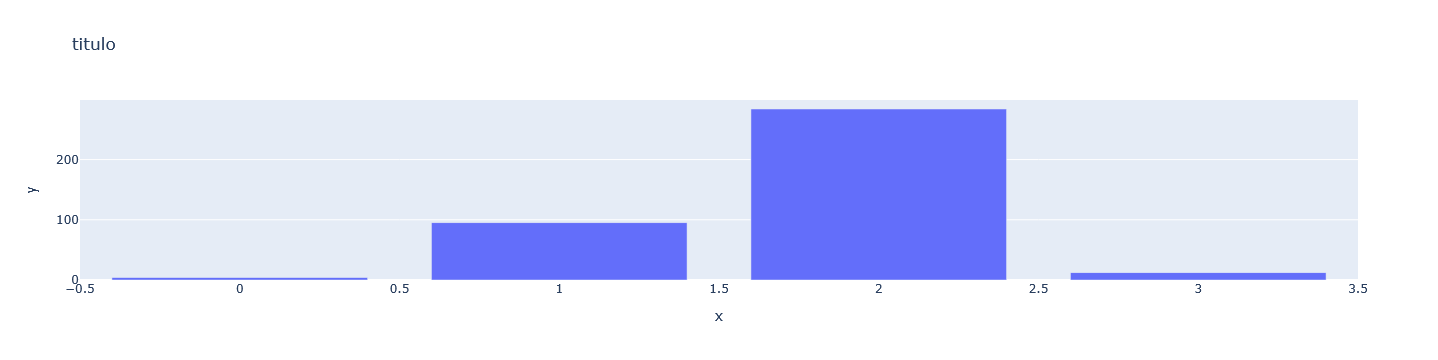

In [14]:
filtr3 = area["tap"].value_counts()
fig = px.bar(
    data_frame = filtr3, x = filtr3.index, y = filtr3.values, title = "titulo")
fig.show()

explicacion: aqui se utilizo la herramienta potly bar, filtrando por tap, para mostrar cual area tipo jurisdiccion es mas frecuente. (x = valor y = frecuencia)

2.grafico: ¿Cuál es el tipo de área protegida (tap) mayor a la longitud (lng) promedio mas frecuente?

          Respuesta:

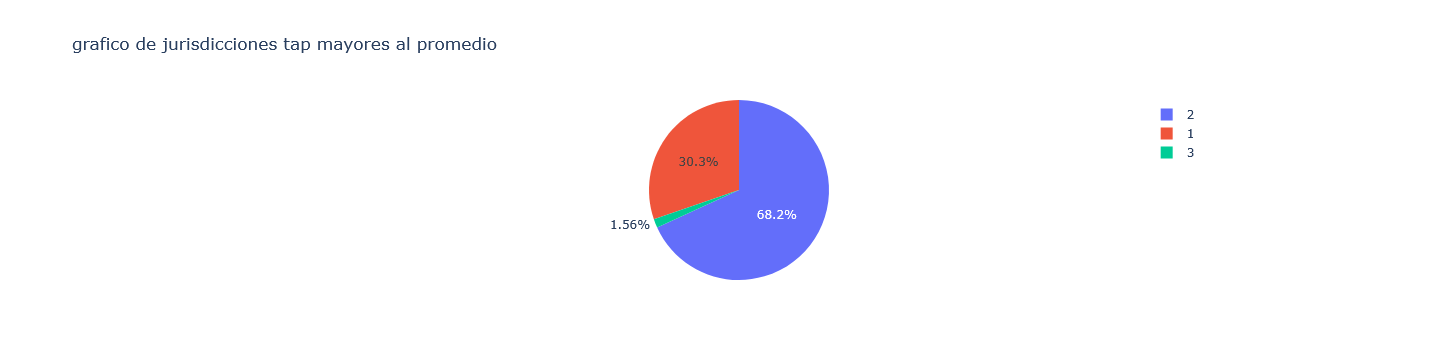

In [7]:
filtr2 = area[area["lng"] > -63]
filtr3 = filtr2["tap"]
pig = px.pie(
    data_frame = filtr3, values = filtr3.index, names = filtr3.values, title = "grafico de jurisdicciones tap mayores al promedio")
pig.show()

explicacion: aqui se utilizo la herramienta poylt pie, se filtro por dos variables distintas; una que guardaba el promedio de longitud lng, y otra que lo filtraba por tipo tap.

3.grafico: utilizando potly line; queremos generar un grafico que muestre la latitud de todas las areas protegidas; parques nacionales ("tap 1" y "jap 2") menores al promedio ¿cual es el parque nacional con menos latitud?

      Respuesta:

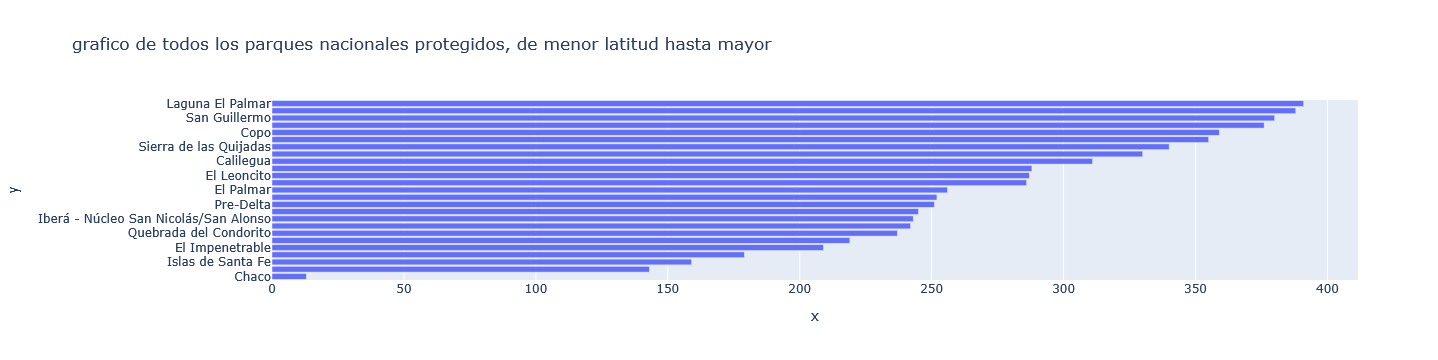

In [10]:
filtr1 = area[(area["tap"] == 1)&(area.jap == 2)]
filtr2 = filtr1[filtr1["lat"] > -34]
filtr3 = filtr2["nam"]
dig = px.bar(
    filtr3, y = filtr3.values, x = filtr3.index, title = "grafico de todos los parques nacionales protegidos, de menor latitud hasta mayor")
dig.show()


Explicacion: utilizando la funcion "&" para adjuntar dos instancias como una sola variable (parques naciones = tap 1 y jap 2) y filtrando luego por latitud nombre, con potly line creamos nuestro grafico.

1mapa:filtrar visualmente con un mapa todos las areas protegidas tipo parque(tap = 1)

           Respuesta:

In [17]:
attr = (
    '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> '
    'contributors, &copy; <a href="https://cartodb.com/attributions">CartoDB</a>'
)

tiles = 'https://wms.ign.gob.ar/geoserver/gwc/service/tms/1.0.0/capabaseargenmap@EPSG%3A3857@png/{z}/{x}/{-y}.png'

mapa = folium.Map(
    location=(-33.457606, -65.346857),
    control_scale=True,
    zoom_start=5,
)
folium.TileLayer(
        tiles=tiles,
        attr=attr,
        name="Argenmap IGN",
        tms=True
    ).add_to(mapa)

filtr = area[area["tap"] == 1]

for _, fila in filtr.iterrows():

    folium.Marker(
        location=[fila["lat"], fila["lng"]],
        popup=fila["nam"],
        category_col="Parque"
    ).add_to(mapa)

mapa

explicacion: se establecio una variable con folium.map (mapa1 = folium.map("atributos")), entonces map1 es la variable contiene el mapa que vamos a utilizar.
luego se filtro por tap == 1, utilizando una iteracion for y folium.marker (aqui se establecio la latitud y longitud, y popup los nombres por fila), añadiendose finalmente a nuestra variable mapa.

2mapa:filtrar y diferenciar por color todas las areas protegidas tipo area parque(tap = 1) y jurisdiccion provincial (jap = 3)

        Respuesta:

In [18]:
attr = (
    '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> '
    'contributors, &copy; <a href="https://cartodb.com/attributions">CartoDB</a>'
)

tiles = 'https://wms.ign.gob.ar/geoserver/gwc/service/tms/1.0.0/capabaseargenmap@EPSG%3A3857@png/{z}/{x}/{-y}.png'

filtr1 = area[area["tap"] == 1]

filtr2 = area[area["jap"] == 3]

mapa = folium.Map(
    location=(-33.457606, -65.346857),
    control_scale=True,
    zoom_start=5,
    tiles="OpenStreetMap",

)

folium.TileLayer(
        tiles=tiles,
        attr=attr,
        name="Argenmap IGN",
        tms=True
    ).add_to(mapa)

for _, fila in filtr1.iterrows():

    folium.CircleMarker(
        location=[fila["lat"], fila["lng"]],
        radius=6,
        color="red",
        fill=True,
        fill_color="red",
        popup=fila["nam"]
    ).add_to(mapa)

for _, fila in filtr2.iterrows():

    folium.CircleMarker(
        location=[fila["lat"], fila["lng"]],
        radius=6,
        color="blue",
        fill=True,
        fill_color="blue",
        popup=fila["nam"]
    ).add_to(mapa)

mapa

explicacion: aqui añadi dos variables, cada una filtrando tap = 1 y jap = 3.
    cada folium.circlemarker representa la forma que se filtraran por color su variable correspondiente en el mapa.